In [1]:
from dinov2 import embed_action, load_json, load_or_build_cache, build_dataset
import os, json
from pathlib import Path
import joblib
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import timm
import torchvision.transforms as T
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

from frame_extraction import extract_frames_from_video
X_foul_train, y_foul_train, _, _ = load_or_build_cache(
    "C:/Users/Evang/Desktop/Work/DS440/cached_X_foul_train.pkl",
    "C:/Users/Evang/Desktop/Work/DS440/codes/train_foul.json"
)
X_foul_test,  y_foul_test,  _, _ = load_or_build_cache(
    "C:/Users/Evang/Desktop/Work/DS440/cached_X_foul_test.pkl",
    "C:/Users/Evang/Desktop/Work/DS440/codes/balanced_data.json"
)

X_ca_train, _, y_card_train, y_adv_train = load_or_build_cache(
    "C:/Users/Evang/Desktop/Work/DS440/cached_X_ca_train.pkl",
    "C:/Users/Evang/Desktop/Work/DS440/codes/train_card_adv.json"
)

X_ca_test,  _, y_card_test,  y_adv_test  = load_or_build_cache(
    "C:/Users/Evang/Desktop/Work/DS440/cached_X_ca_test.pkl",
    "C:/Users/Evang/Desktop/Work/DS440/codes/balanced_fouls_data.json"
)

foul_mlp = joblib.load("C:/Users/Evang/Desktop/Work/DS440/saved_models/foul_mlp.pkl")
card_mlp = joblib.load("C:/Users/Evang/Desktop/Work/DS440/saved_models/card_mlp.pkl")
adv_mlp  = joblib.load("C:/Users/Evang/Desktop/Work/DS440/saved_models/adv_mlp.pkl")
card_encoder = joblib.load("C:/Users/Evang/Desktop/Work/DS440/saved_models/card_label_encoder.pkl")
y_card_train_enc = card_encoder.fit_transform(y_card_train)
y_card_test_enc = card_encoder.transform(y_card_test)

C:\Users\Evang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading cached dataset: C:/Users/Evang/Desktop/Work/DS440/cached_X_foul_train.pkl
Loading cached dataset: C:/Users/Evang/Desktop/Work/DS440/cached_X_foul_test.pkl
Loading cached dataset: C:/Users/Evang/Desktop/Work/DS440/cached_X_ca_train.pkl
Loading cached dataset: C:/Users/Evang/Desktop/Work/DS440/cached_X_ca_test.pkl


In [2]:
y_foul_train_pred = foul_mlp.predict(X_foul_train)
train_acc_foul = accuracy_score(y_foul_train, y_foul_train_pred)

y_card_train_pred = card_mlp.predict(X_ca_train)
train_acc_card = accuracy_score(y_card_train_enc, y_card_train_pred)
print("Foul train acc:", train_acc_foul)
print("Card train acc:", train_acc_card)

Foul train acc: 0.974308300395257
Card train acc: 0.7488789237668162


In [3]:
y_foul_test_pred = foul_mlp.predict(X_foul_test)
test_acc_foul = accuracy_score(y_foul_test, y_foul_test_pred)

y_card_test_pred = card_mlp.predict(X_ca_test)
test_acc_card = accuracy_score(y_card_test_enc, y_card_test_pred)
print("Foul test acc:", test_acc_foul)
print("Card test acc:", test_acc_card)

Foul test acc: 0.5
Card test acc: 0.41379310344827586


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score

# Hyperparameter tuning for Foul classifier
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        n_jobs=-1
    ))
])

param_grid = {
    "pca__n_components": [8, 16, 32, 64],
    "clf__C": [0.01, 0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid.fit(X_foul_train, y_foul_train)

print("Best params:", grid.best_params_)
print("CV best acc:", grid.best_score_)

best_foul_clf = grid.best_estimator_
y_foul_pred = best_foul_clf.predict(X_foul_test)
print("Test acc:", accuracy_score(y_foul_test, y_foul_pred))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'clf__C': 0.1, 'pca__n_components': 64}
CV best acc: 0.6935934769947585
Test acc: 0.52


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=128, random_state=42)

# Foul, PCA and Logistic Regression
foul_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=16, random_state=42)),
    ("clf", LogisticRegression(
        max_iter=5000,
        n_jobs=-1
    ))
])

foul_clf.fit(X_foul_train, y_foul_train)

y_foul_pred = foul_clf.predict(X_foul_test)
acc_foul = accuracy_score(y_foul_test, y_foul_pred)
print("Foul test acc (PCA+LR):", acc_foul)


# Card
card_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=32, random_state=42)),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        early_stopping=True,
        n_iter_no_change=30,
        max_iter=500,
        random_state=42
    ))
])

card_clf.fit(X_ca_train, y_card_train_enc)

y_card_pred_enc = card_clf.predict(X_ca_test)
acc_card = accuracy_score(y_card_test_enc, y_card_pred_enc)
print("Card test acc (PCA+MLP):", acc_card)

# Advantage
adv_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=16, random_state=42)),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        n_jobs=-1
    ))
])

adv_clf.fit(X_ca_train, y_adv_train)

y_adv_pred = adv_clf.predict(X_ca_test)
acc_adv = accuracy_score(y_adv_test, y_adv_pred)
print("Advantage test acc (PCA+LR):", acc_adv)

Foul test acc (PCA+LR): 0.62
Card test acc (PCA+MLP): 0.5116279069767442
Advantage test acc (PCA+LR): 0.7209302325581395


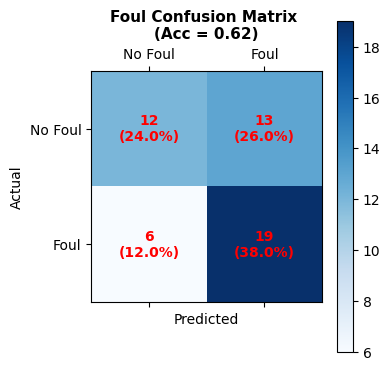

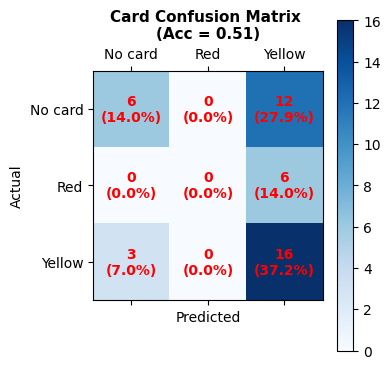

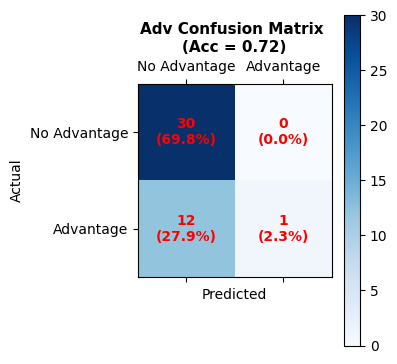

In [12]:
from dinov2 import plot_confusion_matrix

cm_foul = confusion_matrix(y_foul_test, y_foul_pred)
plot_confusion_matrix(
    cm_foul,
    ["No Foul", "Foul"],
    f"Foul Confusion Matrix \n(Acc = {acc_foul:.2f})"
)

cm_card = confusion_matrix(y_card_test_enc, y_card_pred_enc)
plot_confusion_matrix(
    cm_card,
    card_encoder.classes_,
    f"Card Confusion Matrix \n(Acc = {acc_card:.2f})"
)

cm_adv = confusion_matrix(y_adv_test, y_adv_pred)
plot_confusion_matrix(
    cm_adv,
    ["No Advantage", "Advantage"],
    f"Adv Confusion Matrix \n(Acc = {acc_adv:.2f})"
)